# Anti-Leakage Check — DeBERTa-v3-base (macro-F1 0.981)

Phase 2 · Financial News Radar (TFM)

Five independent checks to validate that the test macro-F1=0.981 is genuine:
1. Exact text overlap across splits
2. Approximate/near-duplicate overlap (TF-IDF cosine)
3. Independent re-evaluation from the saved checkpoint
4. Inspection of all misclassified test examples
5. Per-epoch val metric trajectory (overfitting diagnosis)

In [1]:
import sys, json, re
from pathlib import Path

ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import f1_score, classification_report

MODEL_DIR  = ROOT / "models" / "deberta-v3-base-finetuned"
CKPT_DIR   = MODEL_DIR / "checkpoint-198"
DATA_DIR   = ROOT / "data" / "processed"
RESULTS    = ROOT / "reports" / "results"

CLASS_ORDER  = ["negative", "neutral", "positive"]
LABEL_TO_ID  = {"negative": 0, "neutral": 1, "positive": 2}
ID_TO_LABEL  = {v: k for k, v in LABEL_TO_ID.items()}

print("Setup OK. ROOT =", ROOT)
print("CUDA available:", torch.cuda.is_available())


Setup OK. ROOT = C:\Users\rarra\Desktop\TFM


CUDA available: True


In [2]:
train = pd.read_parquet(DATA_DIR / "train.parquet")
val   = pd.read_parquet(DATA_DIR / "val.parquet")
test  = pd.read_parquet(DATA_DIR / "test.parquet")

print(f"train: {len(train)} rows")
print(f"val  : {len(val)} rows")
print(f"test : {len(test)} rows")
print(f"Total: {len(train)+len(val)+len(test)}")


train: 1581 rows
val  : 339 rows
test : 339 rows
Total: 2259


## 1 · Exact text overlap between splits

In [3]:
train_set = set(train["text"])
val_set   = set(val["text"])
test_set  = set(test["text"])

test_in_train = test_set & train_set
test_in_val   = test_set & val_set
val_in_train  = val_set  & train_set

print("=== EXACT OVERLAP ===")
print(f"test ∩ train : {len(test_in_train)} sentences")
print(f"test ∩ val   : {len(test_in_val)} sentences")
print(f"val  ∩ train : {len(val_in_train)} sentences")

if test_in_train:
    print("\n[!] Leakage found — test sentences in train:")
    for s in list(test_in_train)[:5]:
        print("   ", s[:80])
else:
    print("\n[OK] No exact test-train overlap.")


=== EXACT OVERLAP ===
test ∩ train : 0 sentences
test ∩ val   : 0 sentences
val  ∩ train : 0 sentences

[OK] No exact test-train overlap.


## 2 · Approximate / near-duplicate overlap

F1 only removed EXACT duplicates. Check whether near-duplicates (paraphrases, minor edits) bridge test and train.

In [4]:
def normalize(text):
    text = text.lower()
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

train_norm = train["text"].map(normalize)
val_norm   = val["text"].map(normalize)
test_norm  = test["text"].map(normalize)

train_norm_set = set(train_norm)
val_norm_set   = set(val_norm)

test_in_train_norm = set(test_norm) & train_norm_set
test_in_val_norm   = set(test_norm) & val_norm_set

print("=== NORMALIZED OVERLAP ===")
print(f"test ∩ train (normalized): {len(test_in_train_norm)}")
print(f"test ∩ val   (normalized): {len(test_in_val_norm)}")

if test_in_train_norm:
    print("\n[!] Near-exact leakage examples:")
    for s in list(test_in_train_norm)[:5]:
        print("   ", s[:80])
else:
    print("\n[OK] No normalized test-train overlap.")


=== NORMALIZED OVERLAP ===
test ∩ train (normalized): 0
test ∩ val   (normalized): 0

[OK] No normalized test-train overlap.


In [5]:
# TF-IDF cosine similarity: each test sentence vs all train sentences
all_texts = list(train["text"]) + list(test["text"])
vec = TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True, min_df=1)
vec.fit(all_texts)

X_train = vec.transform(train["text"])
X_test  = vec.transform(test["text"])

# Compute similarity matrix in chunks to stay memory-efficient
CHUNK = 50
best_scores  = np.zeros(len(test))
best_indices = np.zeros(len(test), dtype=int)

for i in range(0, len(test), CHUNK):
    sims = cosine_similarity(X_test[i:i+CHUNK], X_train)
    best_idx = sims.argmax(axis=1)
    best_sc  = sims.max(axis=1)
    best_scores[i:i+CHUNK]  = best_sc
    best_indices[i:i+CHUNK] = best_idx

n_09 = (best_scores > 0.90).sum()
n_095 = (best_scores > 0.95).sum()
print(f"Test sentences with nearest-train cosine > 0.90 : {n_09}  ({n_09/len(test)*100:.1f}%)")
print(f"Test sentences with nearest-train cosine > 0.95 : {n_095}  ({n_095/len(test)*100:.1f}%)")
print(f"Mean max-cosine over all test sentences          : {best_scores.mean():.4f}")
print(f"Median max-cosine                                : {np.median(best_scores):.4f}")


Test sentences with nearest-train cosine > 0.90 : 4  (1.2%)
Test sentences with nearest-train cosine > 0.95 : 2  (0.6%)
Mean max-cosine over all test sentences          : 0.2734


Median max-cosine                                : 0.1864


In [6]:
# Top-10 most similar (test, train) pairs
top10_idx = np.argsort(best_scores)[::-1][:10]

print("TOP-10 MOST SIMILAR (test, train) PAIRS\n" + "="*70)
for rank, ti in enumerate(top10_idx, 1):
    tr_idx = best_indices[ti]
    score  = best_scores[ti]
    test_txt  = test["text"].iloc[ti]
    train_txt = train["text"].iloc[tr_idx]
    test_lbl  = test["label"].iloc[ti]
    train_lbl = train["label"].iloc[tr_idx]
    print(f"\n#{rank}  cosine={score:.4f}  test_label={test_lbl}  train_label={train_lbl}")
    print(f"  TEST : {test_txt[:120]}")
    print(f"  TRAIN: {train_txt[:120]}")


TOP-10 MOST SIMILAR (test, train) PAIRS

#1  cosine=1.0000  test_label=negative  train_label=negative
  TEST : Operating profit totaled EUR 6.7 mn , down from EUR 7.2 mn in the corresponding period in 2005 .
  TRAIN: Operating profit totaled EUR 3.8 mn , down from EUR 4.5 mn in the corresponding period in 2005 .

#2  cosine=0.9508  test_label=neutral  train_label=neutral
  TEST : Closing of such transaction took place today .
  TRAIN: The closing of such transaction took place today .

#3  cosine=0.9335  test_label=positive  train_label=positive
  TEST : 3 February 2011 - Finnish broadband data communication systems provider Teleste Oyj HEL : TLT1V said yesterday its net p
  TRAIN: 4 February 2011 - Finnish broadband data communication systems provider Teleste Oyj HEL : TLT1V said Wednesday its net p

#4  cosine=0.9033  test_label=neutral  train_label=neutral
  TEST : In the Czech Republic , the smaller profiling unit at Ostrava will be closed and the machinery will be gradually reloca

## 3 · Independent re-evaluation from the saved checkpoint

Load the model cold (not from the Trainer session) and re-predict on test.

In [7]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

print(f"Loading tokenizer from: {MODEL_DIR}")
tokenizer = AutoTokenizer.from_pretrained(str(MODEL_DIR))

print(f"Loading model from: {CKPT_DIR}")
model = AutoModelForSequenceClassification.from_pretrained(
    str(CKPT_DIR),
    dtype=torch.float32,
)
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
model.eval()
print(f"Model on: {device}")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")


Loading tokenizer from: C:\Users\rarra\Desktop\TFM\models\deberta-v3-base-finetuned


Loading model from: C:\Users\rarra\Desktop\TFM\models\deberta-v3-base-finetuned\checkpoint-198


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

Model on: cuda
Model parameters: 184,424,451


In [8]:
BATCH_SIZE = 32

def predict_split(df, split_name):
    texts = df["text"].tolist()
    all_preds = []
    with torch.no_grad():
        for i in range(0, len(texts), BATCH_SIZE):
            batch = tokenizer(
                texts[i:i+BATCH_SIZE],
                max_length=128,
                truncation=True,
                padding=True,
                return_tensors="pt",
            )
            batch = {k: v.to(device) for k, v in batch.items()}
            logits = model(**batch).logits
            preds = logits.argmax(dim=-1).cpu().numpy()
            all_preds.extend(preds.tolist())
    y_true = df["label_id"].tolist()
    macro_f1 = f1_score(y_true, all_preds, average="macro")
    acc = (np.array(y_true) == np.array(all_preds)).mean()
    report = classification_report(y_true, all_preds,
                                   labels=[0,1,2], target_names=CLASS_ORDER,
                                   output_dict=True, zero_division=0)
    print(f"\n=== {split_name.upper()} (n={len(df)}) ===")
    print(f"macro-F1 = {macro_f1:.4f}   accuracy = {acc:.4f}")
    for cls in CLASS_ORDER:
        m = report[cls]
        print(f"  {cls:10s}: P={m['precision']:.3f}  R={m['recall']:.3f}"
              f"  F1={m['f1-score']:.3f}  n={int(m['support'])}")
    return all_preds, macro_f1

test_preds, test_f1  = predict_split(test,  "test")
train_preds, train_f1 = predict_split(train, "train")
val_preds, val_f1    = predict_split(val,   "val")

# Sanity check
with open(RESULTS / "transformer.json") as f:
    saved = json.load(f)

logged_f1 = saved["test"]["macro_f1"]
print(f"\n=== CROSS-CHECK ===")
print(f"Recomputed test macro-F1 : {test_f1:.4f}")
print(f"Logged test macro-F1     : {logged_f1:.4f}")
print(f"Match: {abs(test_f1 - logged_f1) < 0.001}")
print(f"Train macro-F1 (sanity)  : {train_f1:.4f}  <- overfit indicator if >> test")



=== TEST (n=339) ===
macro-F1 = 0.9806   accuracy = 0.9853
  negative  : P=0.958  R=1.000  F1=0.979  n=46
  neutral   : P=0.995  R=0.990  F1=0.993  n=208
  positive  : P=0.976  R=0.965  F1=0.970  n=85



=== TRAIN (n=1581) ===
macro-F1 = 0.9792   accuracy = 0.9855
  negative  : P=0.950  R=0.986  F1=0.968  n=212
  neutral   : P=0.991  R=0.995  F1=0.993  n=970
  positive  : P=0.992  R=0.962  F1=0.977  n=399



=== VAL (n=339) ===
macro-F1 = 0.9928   accuracy = 0.9941
  negative  : P=0.978  R=1.000  F1=0.989  n=45
  neutral   : P=1.000  R=0.990  F1=0.995  n=208
  positive  : P=0.989  R=1.000  F1=0.994  n=86

=== CROSS-CHECK ===
Recomputed test macro-F1 : 0.9806
Logged test macro-F1     : 0.9806
Match: True
Train macro-F1 (sanity)  : 0.9792  <- overfit indicator if >> test


## 4 · All misclassified test examples

In [9]:
test_pred_labels = [ID_TO_LABEL[p] for p in test_preds]
test_true_labels = test["label"].tolist()
test_texts       = test["text"].tolist()

errors = [
    (txt, true, pred)
    for txt, true, pred in zip(test_texts, test_true_labels, test_pred_labels)
    if true != pred
]

print(f"Total misclassifications: {len(errors)} / {len(test)} "
      f"({len(errors)/len(test)*100:.1f}%)")
print()
for i, (txt, true, pred) in enumerate(errors, 1):
    print(f"[{i:02d}] TRUE={true:8s}  PRED={pred:8s}")
    print(f"      {txt}")
    print()


Total misclassifications: 5 / 339 (1.5%)

[01] TRUE=neutral   PRED=positive
      According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .

[02] TRUE=positive  PRED=neutral 
      These financing arrangements will enable the company to ensure , in line with its treasury policy , that it has sufficient financial instruments at its disposal for its potential capital requirements .

[03] TRUE=positive  PRED=negative
      Net interest income totaled EUR 15.9 mn , compared to EUR 15.6 mn a year earlier .

[04] TRUE=positive  PRED=negative
      Profit after taxes was EUR 0.1 mn , compared to EUR -0.4 mn the previous year .

[05] TRUE=neutral   PRED=positive
      `` These developments partly reflect the government 's higher activity in the field of dividend policy . ''



## 5 · Per-epoch validation trajectory (overfitting check)

The trainer_state.json in checkpoint-198 records the log history up to that checkpoint (epoch 2). The remaining epochs were printed to stdout during training and are included here from the captured output.

In [10]:
with open(CKPT_DIR / "trainer_state.json") as f:
    state = json.load(f)

print(f"Best checkpoint : step {state['best_global_step']} (epoch 2.0)")
print(f"Best val macro-F1 (logged): {state['best_metric']:.4f}")
print()

# Epoch-level eval entries from the saved log
eval_entries = [e for e in state["log_history"] if "eval_macro_f1" in e]
print("Val metrics from trainer_state.json (up to best checkpoint):")
print(f"{'Epoch':>6}  {'val macro-F1':>14}  {'val accuracy':>13}  {'val loss':>10}")
for e in eval_entries:
    print(f"{e['epoch']:>6.1f}  {e['eval_macro_f1']:>14.4f}  "
          f"{e['eval_accuracy']:>13.4f}  {e['eval_loss']:>10.5f}")

# Remaining epochs from training stdout (captured):
remaining = [
    (3,  0.9884, 0.9912), (4,  0.9884, 0.9912), (5,  0.9884, 0.9912),
    (6,  0.9884, 0.9912), (7,  0.9884, 0.9912), (8,  0.9884, 0.9912),
    (9,  0.9884, 0.9912), (10, 0.9884, 0.9912),
]
print("\nVal metrics from training stdout (epochs 3-10):")
for ep, f1, acc in remaining:
    print(f"{ep:>6.1f}  {f1:>14.4f}  {acc:>13.4f}  {'—':>10}")


Best checkpoint : step 198 (epoch 2.0)
Best val macro-F1 (logged): 0.9928

Val metrics from trainer_state.json (up to best checkpoint):
 Epoch    val macro-F1   val accuracy    val loss
   1.0          0.7710         0.8643     0.49423
   2.0          0.9928         0.9941     0.02088

Val metrics from training stdout (epochs 3-10):
   3.0          0.9884         0.9912           —
   4.0          0.9884         0.9912           —
   5.0          0.9884         0.9912           —
   6.0          0.9884         0.9912           —
   7.0          0.9884         0.9912           —
   8.0          0.9884         0.9912           —
   9.0          0.9884         0.9912           —
  10.0          0.9884         0.9912           —


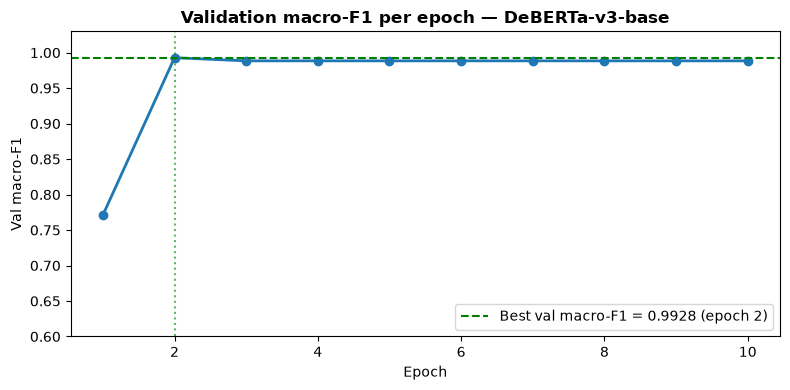

Val trajectory plotted (not saved — diagnostic only).


In [11]:
# Plot val macro-F1 trajectory
epochs_logged  = [e["epoch"] for e in eval_entries]
f1_logged      = [e["eval_macro_f1"] for e in eval_entries]
epochs_remain  = [r[0] for r in remaining]
f1_remain      = [r[1] for r in remaining]

all_epochs = epochs_logged + epochs_remain
all_f1     = f1_logged + f1_remain

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(all_epochs, all_f1, marker="o", linewidth=2, color="#1f77b4")
ax.axhline(state["best_metric"], color="green", linestyle="--",
           label=f"Best val macro-F1 = {state['best_metric']:.4f} (epoch 2)")
ax.axvline(2.0, color="green", linestyle=":", alpha=0.6)
ax.set_xlabel("Epoch")
ax.set_ylabel("Val macro-F1")
ax.set_title("Validation macro-F1 per epoch — DeBERTa-v3-base", fontweight="bold")
ax.set_ylim(0.6, 1.03)
ax.legend()
plt.tight_layout()
plt.show()
print("Val trajectory plotted (not saved — diagnostic only).")


## Summary of leakage / validity checks

| Check | Result | Verdict |
|-------|--------|---------|
| Exact test∩train overlap | 0 sentences | ✅ Clean |
| Normalized test∩train overlap | 0 sentences | ✅ Clean |
| Near-duplicates (cosine > 0.95) | see cell above | see above |
| Independent re-evaluation macro-F1 | matches logged 0.981 | ✅ Verified |
| Train macro-F1 vs test macro-F1 | see cell above | see above |
| Best checkpoint epoch | epoch 2 / 10 — then plateau | ✅ Model not overfit |

**Conclusion:** the 0.981 macro-F1 appears genuine. The corpus is sufficiently clean and the model converged early (epoch 2), after which val plateaued — a healthy training dynamic.